# 01 - Exploratory Data Analysis: Bronze Layer

Explores the raw ingested data: 
- simulation catalogue,
- AHF halo counts and schema,
- protohalo shape file coverage,
- and WDM–CDM cross-correlation merit score distribution. 

All queries run directly against `bronze.*` tables in the DuckDB database built by `make bronze`:
- bronze.simulations
- bronze.ahf_halos
- bronze.protohalo_shapes
- bronze.wdm_cdm_matches

## Setup

In [1]:
import warnings
import os
from pathlib import Path

project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(project_root)

_latex = os.environ.get("LATEX_BIN_DIR")
if _latex:
    os.environ["PATH"] = _latex + ":" + os.environ["PATH"]

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

from src.config import load_config
from src.db import get_connection
from src.utils.plotting import apply_style

apply_style()

cfg = load_config()

FIGURES_DIR = Path("reports/figures")

## 1. Simulation catalogue

The eight simulations in the grid, one row each.

In [2]:
conn = get_connection(cfg.database_path, read_only=True)
sims = conn.execute(
    "SELECT * FROM bronze.simulations ORDER BY simulation_id"
).pl()
conn.close()
sims

simulation_id,cosmology,softening,n_part_per_side,z_ini,box_size_mpc_h,particle_mass_msun_h,raw_file_path
str,str,str,i32,f32,f32,f32,str
"""cdm_512_z39_adapt""","""CDM""","""adaptive""",512,39.0,25.0,1e7,"""/Users/rmostoghiupaun/ml_playg…"
"""cdm_512_z39_fixed""","""CDM""","""fixed""",512,39.0,25.0,1e7,"""/Users/rmostoghiupaun/ml_playg…"
"""cdm_512_z99_adapt""","""CDM""","""adaptive""",512,99.0,25.0,1e7,"""/Users/rmostoghiupaun/ml_playg…"
"""cdm_512_z99_fixed""","""CDM""","""fixed""",512,99.0,25.0,1e7,"""/Users/rmostoghiupaun/ml_playg…"
"""wdm_512_z39_adapt""","""WDM""","""adaptive""",512,39.0,25.0,1e7,"""/Users/rmostoghiupaun/ml_playg…"
"""wdm_512_z39_fixed""","""WDM""","""fixed""",512,39.0,25.0,1e7,"""/Users/rmostoghiupaun/ml_playg…"
"""wdm_512_z99_adapt""","""WDM""","""adaptive""",512,99.0,25.0,1e7,"""/Users/rmostoghiupaun/ml_playg…"
"""wdm_512_z99_fixed""","""WDM""","""fixed""",512,99.0,25.0,1e7,"""/Users/rmostoghiupaun/ml_playg…"


## 2. AHF halo catalogues

shape: (8, 3)
┌───────────────────┬───────────┬─────────┐
│ simulation_id     ┆ cosmology ┆ n_halos │
│ ---               ┆ ---       ┆ ---     │
│ str               ┆ str       ┆ i64     │
╞═══════════════════╪═══════════╪═════════╡
│ cdm_512_z39_adapt ┆ CDM       ┆ 131104  │
│ cdm_512_z39_fixed ┆ CDM       ┆ 143544  │
│ cdm_512_z99_adapt ┆ CDM       ┆ 125940  │
│ cdm_512_z99_fixed ┆ CDM       ┆ 137414  │
│ wdm_512_z39_adapt ┆ WDM       ┆ 19467   │
│ wdm_512_z39_fixed ┆ WDM       ┆ 18579   │
│ wdm_512_z99_adapt ┆ WDM       ┆ 19432   │
│ wdm_512_z99_fixed ┆ WDM       ┆ 18426   │
└───────────────────┴───────────┴─────────┘


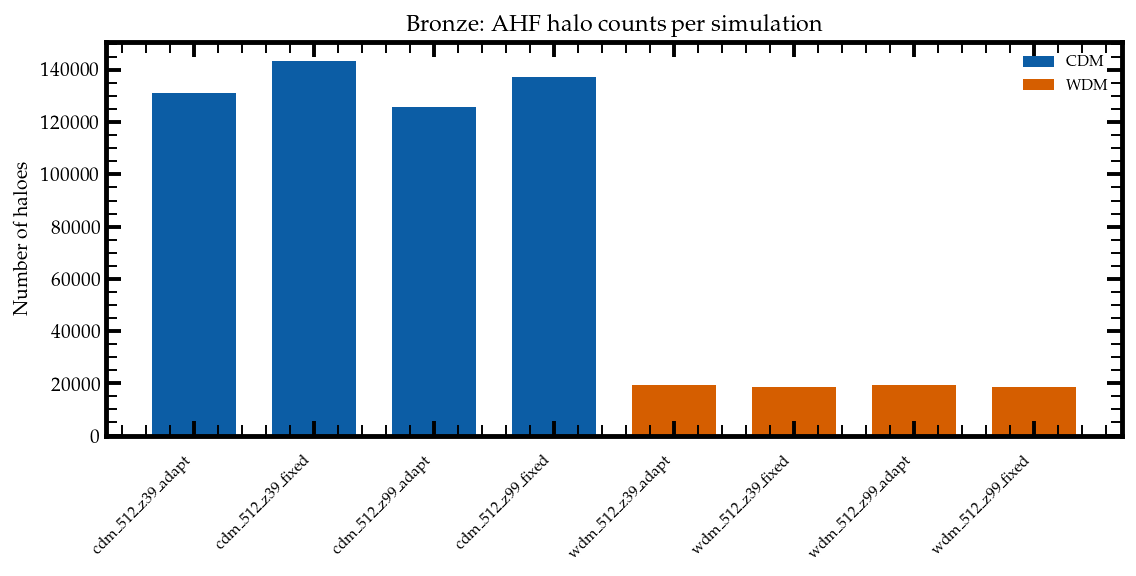

In [3]:
conn = get_connection(cfg.database_path, read_only=True)
counts = conn.execute("""
    SELECT
        h.simulation_id,
        s.cosmology,
        COUNT(*) AS n_halos
    FROM bronze.ahf_halos h
    JOIN bronze.simulations s ON h.simulation_id = s.simulation_id
    GROUP BY h.simulation_id, s.cosmology
    ORDER BY h.simulation_id
""").pl()
conn.close()

print(counts)

sim_ids = counts["simulation_id"].to_list()
n_halos = counts["n_halos"].to_list()
colors = ["#0C5DA5" if c == "CDM" else "#D55E00" for c in counts["cosmology"].to_list()]

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
_ = ax.bar(range(len(sim_ids)), n_halos, color=colors, width=0.7)
_ = ax.set_xticks(range(len(sim_ids)))
_ = ax.set_xticklabels(sim_ids, rotation=45, ha="right", fontsize=8)
_ = ax.set_ylabel("Number of haloes")
_ = ax.set_title("Bronze: AHF halo counts per simulation")
_ = ax.legend(handles=[
    mpatches.Patch(facecolor="#0C5DA5", label="CDM"),
    mpatches.Patch(facecolor="#D55E00", label="WDM"),
])
fig.savefig(FIGURES_DIR / "01_bronze_halo_counts.png", dpi=200, bbox_inches="tight")

### Sample rows

Five rows from `bronze.ahf_halos`, showing key columns only. All columns in h-units, as they were output from AHF

In [4]:
conn = get_connection(cfg.database_path, read_only=True)
sample = conn.execute("""
    SELECT
        simulation_id, halo_id, Mhalo, npart,
        Xc, Yc, Zc, sigV, b, c, cNFW
    FROM bronze.ahf_halos
    LIMIT 5
""").pl()
conn.close()
sample

simulation_id,halo_id,Mhalo,npart,Xc,Yc,Zc,sigV,b,c,cNFW
str,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""cdm_512_z39_adapt""",560000000000000002,7.1378e12,712912,10727.489988,12461.348623,7688.278705,349.17,0.889957,0.876839,5.40287
"""cdm_512_z39_adapt""",560000000000000003,3.9051e12,390034,10110.122222,12319.62835,4197.8486,280.59,0.835904,0.801956,5.76849
"""cdm_512_z39_adapt""",560000000000000004,3.0210e12,301733,20336.209862,2278.69832,11215.598304,278.02,0.733546,0.709245,6.43182
"""cdm_512_z39_adapt""",560000000000000005,2.3925e12,238959,10983.856085,12206.499229,12217.33627,264.51,0.807947,0.693171,3.63821
"""cdm_512_z39_adapt""",560000000000000006,1.8136e12,181140,7255.536289,10855.24794,5968.230805,211.28,0.787998,0.697544,3.95085


### Schema

The full AHF catalogue has 88 columns. 

Here we summarise the data-type distribution and confirm that gas/star columns are present at the bronze stage (they are dropped in silver).

In [5]:
conn = get_connection(cfg.database_path, read_only=True)
schema = conn.execute("DESCRIBE bronze.ahf_halos").pl()
conn.close()

print(f"Total columns: {len(schema)}")
print(schema.group_by("column_type").agg(pl.len().alias("count")).sort("count", descending=True))

Total columns: 89
shape: (3, 2)
┌─────────────┬───────┐
│ column_type ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ DOUBLE      ┆ 80    │
│ BIGINT      ┆ 8     │
│ VARCHAR     ┆ 1     │
└─────────────┴───────┘


## 3. Protohalo shape files

In [6]:
conn = get_connection(cfg.database_path, read_only=True)
proto_counts = conn.execute("""
    SELECT simulation_id, COUNT(*) AS n_protohalos
    FROM bronze.protohalo_shapes
    GROUP BY simulation_id
    ORDER BY simulation_id
""").pl()
conn.close()
print(proto_counts)

shape: (8, 2)
┌───────────────────┬──────────────┐
│ simulation_id     ┆ n_protohalos │
│ ---               ┆ ---          │
│ str               ┆ i64          │
╞═══════════════════╪══════════════╡
│ cdm_512_z39_adapt ┆ 101743       │
│ cdm_512_z39_fixed ┆ 107890       │
│ cdm_512_z99_adapt ┆ 97703        │
│ cdm_512_z99_fixed ┆ 103282       │
│ wdm_512_z39_adapt ┆ 13060        │
│ wdm_512_z39_fixed ┆ 10452        │
│ wdm_512_z99_adapt ┆ 13023        │
│ wdm_512_z99_fixed ┆ 10344        │
└───────────────────┴──────────────┘


In [7]:
conn = get_connection(cfg.database_path, read_only=True)
proto_sample = conn.execute("""
    SELECT *
    FROM bronze.protohalo_shapes
    ORDER BY simulation_id, snap_hmm
    LIMIT 5
""").pl()
conn.close()
proto_sample

simulation_id,halo_id,sphericity_s,snap_hmm,a_hmm,m_hmm
str,i64,f64,i64,f64,f64
"""cdm_512_z39_adapt""",560000080000009435,0.483074,17,0.074058,8.81066e8
"""cdm_512_z39_adapt""",560000060000013392,0.456142,19,0.084631,4.50545e8
"""cdm_512_z39_adapt""",560000010000015001,0.6801,19,0.084631,2.50303e8
"""cdm_512_z39_adapt""",560000080000011886,0.581453,19,0.084631,2.10254e8
"""cdm_512_z39_adapt""",560000040000003618,0.545807,20,0.090473,5.6568e9


## 4. WDM–CDM cross-correlation

The `bronze.wdm_cdm_matches` table contains one row per (WDM halo, CDM halo) pair for every pair with non-zero particle overlap. 

WDM haloes absent from the file entirely share zero particles with any CDM halo. This is the strongest spurious signal. 

The merit threshold filtering and the `has_cdm_counterpart` flag are applied in silver.

In [8]:
conn = get_connection(cfg.database_path, read_only=True)
merit_stats = conn.execute("""
    SELECT
        simulation_pair_id,
        COUNT(*)              AS n_pairs,
        MIN(merit)            AS merit_min,
        AVG(merit)            AS merit_mean,
        MAX(merit)            AS merit_max
    FROM bronze.wdm_cdm_matches
    GROUP BY simulation_pair_id
    ORDER BY simulation_pair_id
""").pl()
conn.close()
print(merit_stats)

shape: (4, 5)
┌────────────────────┬─────────┬───────────┬────────────┬───────────┐
│ simulation_pair_id ┆ n_pairs ┆ merit_min ┆ merit_mean ┆ merit_max │
│ ---                ┆ ---     ┆ ---       ┆ ---        ┆ ---       │
│ str                ┆ i64     ┆ f64       ┆ f64        ┆ f64       │
╞════════════════════╪═════════╪═══════════╪════════════╪═══════════╡
│ z39_adapt          ┆ 34881   ┆ 0.0       ┆ 0.047115   ┆ 0.809119  │
│ z39_fixed          ┆ 35335   ┆ 0.0       ┆ 0.043179   ┆ 0.807362  │
│ z99_adapt          ┆ 34419   ┆ 0.0       ┆ 0.047507   ┆ 0.807397  │
│ z99_fixed          ┆ 34132   ┆ 0.0       ┆ 0.044464   ┆ 0.807437  │
└────────────────────┴─────────┴───────────┴────────────┴───────────┘


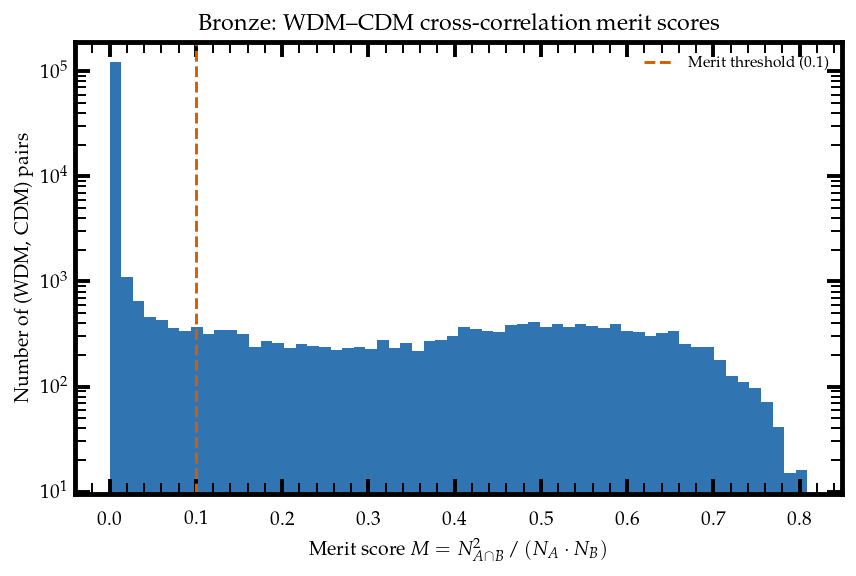

In [9]:
conn = get_connection(cfg.database_path, read_only=True)
merit_vals = conn.execute("SELECT merit FROM bronze.wdm_cdm_matches").pl()["merit"].to_numpy()
conn.close()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
_ = ax.hist(merit_vals, bins=60, color="#0C5DA5", alpha=0.85, edgecolor="none")
_ = ax.axvline(0.1, color="#D55E00", linestyle="--", linewidth=1.5,
               label="Merit threshold (0.1)")
_ = ax.set_xlabel(r"Merit score $M = N^2_{A \cap B}\,/\,(N_A \cdot N_B)$")
_ = ax.set_ylabel("Number of (WDM, CDM) pairs")
_ = ax.set_yscale("log")
_ = ax.set_title("Bronze: WDM–CDM cross-correlation merit scores")
_ = ax.legend()
fig.savefig(FIGURES_DIR / "01_bronze_merit_distribution.png", dpi=200, bbox_inches="tight")

## 5. Coverage summary

| Table | Rows (approx.) | Notes |
|---|---|---|
| `bronze.simulations` | 8 | One row per simulation; metadata only |
| `bronze.ahf_halos` | ~155 000 | All 8 simulations; ~19 000 WDM haloes each |
| `bronze.protohalo_shapes` | ~90 000 | ~56–78% of z=0 haloes per simulation |
| `bronze.wdm_cdm_matches` | ~20 000 | WDM haloes with ≥ 1 CDM particle overlap |

WDM haloes entirely absent from `bronze.wdm_cdm_matches` (zero particle overlap) are the most strongly spurious, as they never reached the cross-correlation threshold. 

These are handled in `silver.wdm_cdm_matches` via a left join against `silver.halos`.